<a href="https://colab.research.google.com/github/r021n/simple-machine-learing/blob/main/Simple_Movie_Recommendation_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fase 1: Persiapan & Eksplorasi Data

## Instalasi Library

In [1]:
!pip install scikit-surprise

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 38.7 MB/s eta 0:00:00


## Import Library

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import zipfile
import urllib.request

## Download dan ekstrak dataset

In [3]:
url = "https://files.grouplens.org/datasets/movielens/ml-100k.zip"
urllib.request.urlretrieve(url, "ml-100k.zip")

with zipfile.ZipFile("ml-100k.zip", "r") as zip_ref:
  zip_ref.extractall(".")

print("Dataset berhasil diunduh dan diekstrak!")

Dataset berhasil diunduh dan diekstrak!


## Load Data Rating & Film

In [4]:
ratings = pd.read_csv(
    "ml-100k/u.data",
    sep="\t",
    names=["user_id", "movie_id", "rating", "timestamp"]
)

movies = pd.read_csv(
    "ml-100k/u.item",
    sep="|",
    encoding="latin-1",
    usecols=[0, 1],
    names=["movie_id", "title"]
)

print(ratings.head())
print(movies.head())

   user_id  movie_id  rating  timestamp
0      196       242       3  881250949
1      186       302       3  891717742
2       22       377       1  878887116
3      244        51       2  880606923
4      166       346       1  886397596
   movie_id              title
0         1   Toy Story (1995)
1         2   GoldenEye (1995)
2         3  Four Rooms (1995)
3         4  Get Shorty (1995)
4         5     Copycat (1995)


## Cek Ukuran & Struktur Data

In [5]:
print(f"Jumlah rating : {len(ratings)}")
print(f"Jumlah user   : {ratings["user_id"].nunique()}")
print(f"Jumlah film   : {ratings["movie_id"].nunique()}")
print("\nInfo ratings :")
print(ratings.info())
print("\nInfo movies  :")
print(movies.info())

Jumlah rating : 100000
Jumlah user   : 943
Jumlah film   : 1682

Info ratings :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   user_id    100000 non-null  int64
 1   movie_id   100000 non-null  int64
 2   rating     100000 non-null  int64
 3   timestamp  100000 non-null  int64
dtypes: int64(4)
memory usage: 3.1 MB
None

Info movies  :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1682 entries, 0 to 1681
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   movie_id  1682 non-null   int64 
 1   title     1682 non-null   object
dtypes: int64(1), object(1)
memory usage: 26.4+ KB
None


## Cek Missing Values

In [6]:
print("Missing values di ratings:")
print(ratings.isnull().sum())

print("\nMissing values di movies:")
print(movies.isnull().sum())

Missing values di ratings:
user_id      0
movie_id     0
rating       0
timestamp    0
dtype: int64

Missing values di movies:
movie_id    0
title       0
dtype: int64


## Statistik Deskriptif Rating

In [7]:
print("Statistik rating:")
print(ratings["rating"].describe())

print(f"\nRentang rating : {ratings['rating'].min()} - {ratings['rating'].max()}")
print(f"Rata-rata rating : {ratings['rating'].mean():.2f}")

Statistik rating:
count    100000.000000
mean          3.529860
std           1.125674
min           1.000000
25%           3.000000
50%           4.000000
75%           4.000000
max           5.000000
Name: rating, dtype: float64

Rentang rating : 1 - 5
Rata-rata rating : 3.53


## Visualisasi Distribusi Rating

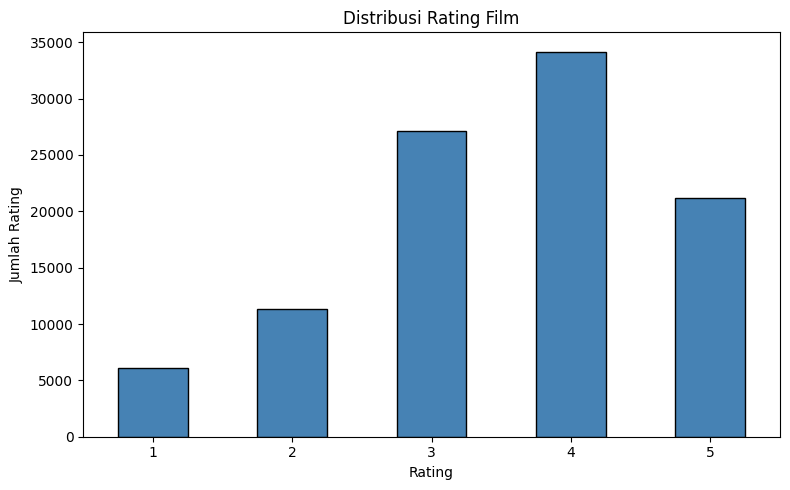

In [8]:
plt.figure(figsize=(8, 5))
ratings["rating"].value_counts().sort_index().plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Distribusi Rating Film")
plt.xlabel("Rating")
plt.ylabel("Jumlah Rating")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Penggabungan Data Rating & Judul Film

In [9]:
merged_df = pd.merge(ratings, movies, on="movie_id")
print(merged_df.head(10))

   user_id  movie_id  rating  timestamp  \
0      196       242       3  881250949   
1      186       302       3  891717742   
2       22       377       1  878887116   
3      244        51       2  880606923   
4      166       346       1  886397596   
5      298       474       4  884182806   
6      115       265       2  881171488   
7      253       465       5  891628467   
8      305       451       3  886324817   
9        6        86       3  883603013   

                                               title  
0                                       Kolya (1996)  
1                           L.A. Confidential (1997)  
2                                Heavyweights (1994)  
3                         Legends of the Fall (1994)  
4                                Jackie Brown (1997)  
5  Dr. Strangelove or: How I Learned to Stop Worr...  
6                   Hunt for Red October, The (1990)  
7                            Jungle Book, The (1994)  
8                              

## Menampilkan Film dengan Rating Terbanyak

In [10]:
top_rated_movies = (
    merged_df.groupby("title")["rating"]
    .count()
    .sort_values(ascending=False)
    .head(10)
)

print("10 Film dengan jumlah rating terbanyak:")
print(top_rated_movies)

10 Film dengan jumlah rating terbanyak:
title
Star Wars (1977)                 583
Contact (1997)                   509
Fargo (1996)                     508
Return of the Jedi (1983)        507
Liar Liar (1997)                 485
English Patient, The (1996)      481
Scream (1996)                    478
Toy Story (1995)                 452
Air Force One (1997)             431
Independence Day (ID4) (1996)    429
Name: rating, dtype: int64


# Fase 2: Content-Based Filtering

## Load Data Film Beserta Genre

In [11]:
genre_columns = [
    "unknown", "Action", "Adventure", "Animation", "Childrens",
    "Comedy", "Crime", "Documentary", "Fantasy",
    "Horror", "Mystery", "Romance",
    "Sci-Fi", "Thriller", "War", "Western", "FilmNoir", "Musical", "Drama"
]

movies_with_genres = pd.read_csv(
    "ml-100k/u.item",
    sep="|",
    encoding="latin-1",
    names=["movie_id", "title", "release_date", "video_release_date", "imdb_url"] + genre_columns
)

print(movies_with_genres[["movie_id", "title"] + genre_columns].head())

   movie_id              title  unknown  Action  Adventure  Animation  \
0         1   Toy Story (1995)        0       0          0          1   
1         2   GoldenEye (1995)        0       1          1          0   
2         3  Four Rooms (1995)        0       0          0          0   
3         4  Get Shorty (1995)        0       1          0          0   
4         5     Copycat (1995)        0       0          0          0   

   Childrens  Comedy  Crime  Documentary  ...  Horror  Mystery  Romance  \
0          1       1      0            0  ...       0        0        0   
1          0       0      0            0  ...       0        0        0   
2          0       0      0            0  ...       0        0        0   
3          0       1      0            0  ...       0        0        0   
4          0       0      1            0  ...       0        0        0   

   Sci-Fi  Thriller  War  Western  FilmNoir  Musical  Drama  
0       0         0    0        0         0     

## Konversi Genre Biner ke Teks

In [12]:
def genres_to_string(row):
  genres = [genre for genre in genre_columns if row[genre] == 1]
  return " ".join(genres)

movies_with_genres["genre_str"] = movies_with_genres.apply(genres_to_string, axis=1)

print(movies_with_genres[["title", "genre_str"]].head(10))

                                               title  \
0                                   Toy Story (1995)   
1                                   GoldenEye (1995)   
2                                  Four Rooms (1995)   
3                                  Get Shorty (1995)   
4                                     Copycat (1995)   
5  Shanghai Triad (Yao a yao yao dao waipo qiao) ...   
6                              Twelve Monkeys (1995)   
7                                        Babe (1995)   
8                            Dead Man Walking (1995)   
9                                 Richard III (1995)   

                    genre_str  
0  Animation Childrens Comedy  
1   Action Adventure FilmNoir  
2                    FilmNoir  
3       Action Comedy Fantasy  
4      Crime Fantasy FilmNoir  
5                     Fantasy  
6             Fantasy Western  
7    Childrens Comedy Fantasy  
8                     Fantasy  
9             Fantasy Musical  


## Menerapkan TF-IDF pada Genre

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(token_pattern=r"(?u)\b\w+(?:-\w+)*\b")
tfidf_matrix = tfidf.fit_transform(movies_with_genres["genre_str"])

print(f"Ukuran TF-IDF Matrix: {tfidf_matrix.shape}")
print(f"Daftar genre (fitur): {tfidf.get_feature_names_out()}")

Ukuran TF-IDF Matrix: (1682, 19)
Daftar genre (fitur): ['action' 'adventure' 'animation' 'childrens' 'comedy' 'crime'
 'documentary' 'drama' 'fantasy' 'filmnoir' 'horror' 'musical' 'mystery'
 'romance' 'sci-fi' 'thriller' 'unknown' 'war' 'western']


## Menghitung Cosine Similarity

In [14]:
from sklearn.metrics.pairwise import cosine_similarity

cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

print(f"Ukuran Cosine Similarity Matrix: {cosine_sim.shape}")
print(f"Contoh nilai similarity baris pertama :\n{cosine_sim[0][:10]}")

Ukuran Cosine Similarity Matrix: (1682, 1682)
Contoh nilai similarity baris pertama :
[1.         0.         0.         0.18860189 0.         0.
 0.         0.61615915 0.         0.        ]


## Membuat Index Judul Film

In [15]:
movies_with_genres = movies_with_genres.reset_index(drop=True)
title_to_index = pd.Series(movies_with_genres.index, index=movies_with_genres["title"])

print("Contoh index beberapa film:")
print(title_to_index.head(5))

Contoh index beberapa film:
title
Toy Story (1995)     0
GoldenEye (1995)     1
Four Rooms (1995)    2
Get Shorty (1995)    3
Copycat (1995)       4
dtype: int64


## Membuat Fungsi Rekomendasi

In [16]:
def get_content_recommendations(title, top_n=10):
  if title not in title_to_index:
    return f"Film '{title}' tidak ditemukan dalam dataset"

  idx = title_to_index[title]
  sim_scores = list(enumerate(cosine_sim[idx]))
  sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
  sim_scores = sim_scores[1:top_n + 1]

  movie_indices = [i[0] for i in sim_scores]
  result = movies_with_genres[["title", "genre_str"]].iloc[movie_indices].copy()
  result["similarity_score"] = [round(i[1], 4) for i in sim_scores]

  return result.reset_index(drop=True)

## Menguji Fungsi Rekomendasi

In [17]:
test_movie = "Toy Story (1995)"

print(f"Rekomendasi film mirip dengan '{test_movie}':\n")
recommendations = get_content_recommendations(test_movie, top_n=10)
print(recommendations.to_string(index=False))

Rekomendasi film mirip dengan 'Toy Story (1995)':

                                                        title                  genre_str  similarity_score
                       Aladdin and the King of Thieves (1996) Animation Childrens Comedy             1.000
                                       Aristocats, The (1970)        Animation Childrens             0.937
                                             Pinocchio (1940)        Animation Childrens             0.937
                               Sword in the Stone, The (1963)        Animation Childrens             0.937
                                Fox and the Hound, The (1981)        Animation Childrens             0.937
                  Winnie the Pooh and the Blustery Day (1968)        Animation Childrens             0.937
                                                 Balto (1995)        Animation Childrens             0.937
                                      Oliver & Company (1988)        Animation Childrens     

## Visualisasi Similarity Score

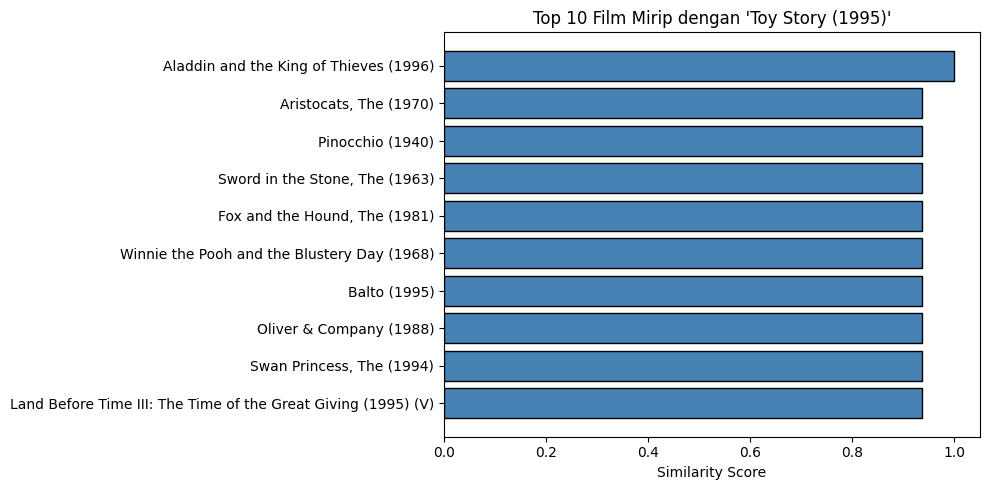

In [18]:
plt.figure(figsize=(10, 5))
plt.barh(
    recommendations["title"],
    recommendations["similarity_score"],
    color="steelblue",
    edgecolor="black"
)
plt.xlabel("Similarity Score")
plt.title(f"Top 10 Film Mirip dengan '{test_movie}'")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Fase 3: Collaborative Filtering

## Import Library Surprise

In [19]:
from surprise import Dataset, Reader, SVD
from surprise.model_selection import train_test_split
from collections import defaultdict

## Menyiapkan Data ke Format Surprise

In [20]:
reader = Reader(rating_scale=(1, 5))
surprise_data = Dataset.load_from_df(ratings[["user_id", "movie_id", "rating"]], reader)

print("Data berhasil dimuat ke format Surprise!")
print(f"Jumlah total rating : {len(ratings)}")

Data berhasil dimuat ke format Surprise!
Jumlah total rating : 100000


## Split Data Train & Test


In [21]:
trainset, testset = train_test_split(surprise_data, test_size=0.2, random_state=42)

print(f"Jumlah data training: {trainset.n_ratings}")
print(f"Jumlah data testing : {len(testset)}")

Jumlah data training: 80000
Jumlah data testing : 20000


## Membangun & Melatih Model SVD (Singluar Value Decomposision)

In [22]:
svd_model = SVD(n_factors=100, n_epochs=20, random_state=42)
svd_model.fit(trainset)

print("Model SVD berhasil dilatih")

Model SVD berhasil dilatih


## Mencoba Prediksi Rating Oleh Model pada Satu Film

In [23]:
sample_user_id = 1
sample_movie_id = 302

prediction = svd_model.predict(sample_user_id, sample_movie_id)

print(f"User ID         : {prediction.uid}")
print(f"Movie ID        : {prediction.iid}")
print(f"Rating Aktual   : {prediction.r_ui}")
print(f"Rating prediksi : {prediction.est:.2f}")

User ID         : 1
Movie ID        : 302
Rating Aktual   : None
Rating prediksi : 4.52


## Membuat Fungsi Rekomendasi Collaborative

In [24]:
def get_collaborative_recommendations(user_id, top_n=10):
  all_movie_ids = ratings["movie_id"].unique()
  watched_movie_ids = ratings[ratings["user_id"] == user_id]["movie_id"].values
  unwatched_movie_ids = [mid for mid in all_movie_ids if mid not in watched_movie_ids]

  predictions = [svd_model.predict(user_id, mid) for mid in unwatched_movie_ids]
  predictions.sort(key=lambda x: x.est, reverse=True)
  top_predictions = predictions[:top_n]

  recommended_ids = [pred.iid for pred in top_predictions]
  predicted_ratings = [round(pred.est, 2) for pred in top_predictions]

  result = movies[movies["movie_id"].isin(recommended_ids)].copy()
  rating_map = dict(zip(recommended_ids, predicted_ratings))
  result["predicted_rating"] = result["movie_id"].map(rating_map)
  result = result.sort_values("predicted_rating", ascending=False).reset_index(drop=True)

  return result

## Menguji Fungsi Rekomendasi

In [25]:
test_user_id = 1

print(f"Film yang direkomendasikan untuk User ID {test_user_id}:\n")
collab_recommendations = get_collaborative_recommendations(test_user_id, top_n=10)
print(collab_recommendations[["title", "predicted_rating"]].to_string(index=False))

Film yang direkomendasikan untuk User ID 1:

                                                                      title  predicted_rating
Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1963)              4.94
                                     One Flew Over the Cuckoo's Nest (1975)              4.94
                                                         Rear Window (1954)              4.93
                                                    Schindler's List (1993)              4.69
                                                      Third Man, The (1949)              4.68
                                               To Kill a Mockingbird (1962)              4.67
                                                          Casablanca (1942)              4.64
                                           Manchurian Candidate, The (1962)              4.55
                                                      Close Shave, A (1995)              4.53
               

## Lihat Riwayat Tontonan User

In [26]:
watched_by_user = (
    merged_df[merged_df["user_id"] == test_user_id]
    .sort_values("rating", ascending=False)
    .head(10)
)

print(f"10 Film dengan rating tertinggi dari User ID {test_user_id}:\n")
print(watched_by_user[["title", "rating"]].to_string(index=False))

10 Film dengan rating tertinggi dari User ID 1:

                                                 title  rating
                             Back to the Future (1985)       5
                        When Harry Met Sally... (1989)       5
                       Nikita (La Femme Nikita) (1990)       5
                             Three Colors: Blue (1993)       5
                                      Lone Star (1996)       5
                             Breaking the Waves (1996)       5
                               Jean de Florette (1986)       5
                      Shawshank Redemption, The (1994)       5
Wallace & Gromit: The Best of Aardman Animation (1996)       5
                   Star Trek: The Wrath of Khan (1982)       5


## Visualisasi Hasil Rekomendasi

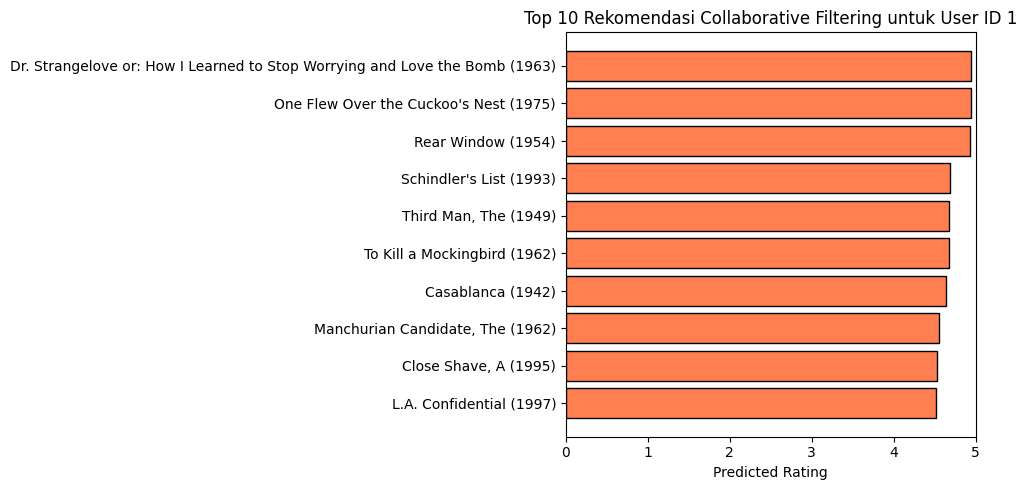

In [28]:
plt.figure(figsize=(10, 5))
plt.barh(
    collab_recommendations["title"],
    collab_recommendations["predicted_rating"],
    color="coral",
    edgecolor="black"
)
plt.xlabel("Predicted Rating")
plt.title(f"Top 10 Rekomendasi Collaborative Filtering untuk User ID {test_user_id}")
plt.xlim(0, 5)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()